# EDA — synthetic transaction dataset

Exploratory pass over the output of `data_sim.simulate` (see `PLAN.md` §03 and `docs/adr/0001-llm-provider-and-hosting-stack.md`). Goal here is not modeling yet — it's confirming the generator produced something realistic and checking for the failure modes called out in the risk register (`PLAN.md` §12): unrealistic distributions, and label leakage (a typology that's trivially separable on a single raw field, which would make Week 2/3 precision numbers meaningless).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/simulated")
customers = pd.read_parquet(DATA_DIR / "customers.parquet")
transactions = pd.read_parquet(DATA_DIR / "transactions.parquet")
manifest = json.loads((DATA_DIR / "manifest.json").read_text())
manifest

{'seed': 42,
 'n_customers': 12000,
 'n_transactions': 1219924,
 'n_base_transactions': 1201068,
 'anomaly_rate_target': 0.02,
 'anomaly_rate_actual': 0.01545670058134769,
 'typology_counts': {'structuring': 4010,
  'layering': 2683,
  'round_amount': 3206,
  'velocity_spike': 4000,
  'peer_deviation': 1987,
  'geographic_risk': 2970},
 'start_date': '2024-01-01',
 'end_date': '2025-06-30',
 'reporting_threshold': 10000.0,
 'generation_seconds': 24.1}

## Scale check

Sanity check against the CV-bullet target of a 1.2M-row simulated dataset, and against the configured anomaly injection rate.

In [2]:
print(f"customers: {len(customers):,}")
print(f"transactions: {len(transactions):,}")
print(f"date span: {transactions.timestamp.min()} -> {transactions.timestamp.max()}")
print(f"anomaly rate: {transactions.is_anomalous.mean():.3%} (target {manifest['anomaly_rate_target']:.1%})")
print(f"nulls in amount: {transactions.amount.isna().sum()}, non-positive: {(transactions.amount <= 0).sum()}")

customers: 12,000
transactions: 1,219,924
date span: 2024-01-01 00:00:00 -> 2025-07-01 03:12:58.643835065
anomaly rate: 1.546% (target 2.0%)
nulls in amount: 0, non-positive: 0


## Customer population

Segment mix and declared risk rating should roughly match the weights set in `data_sim/config.py` (80/15/5 retail/SME/private-banking; 75/20/5 low/medium/high risk) — this confirms the generator's sampling is behaving as configured before we build features on top of it.

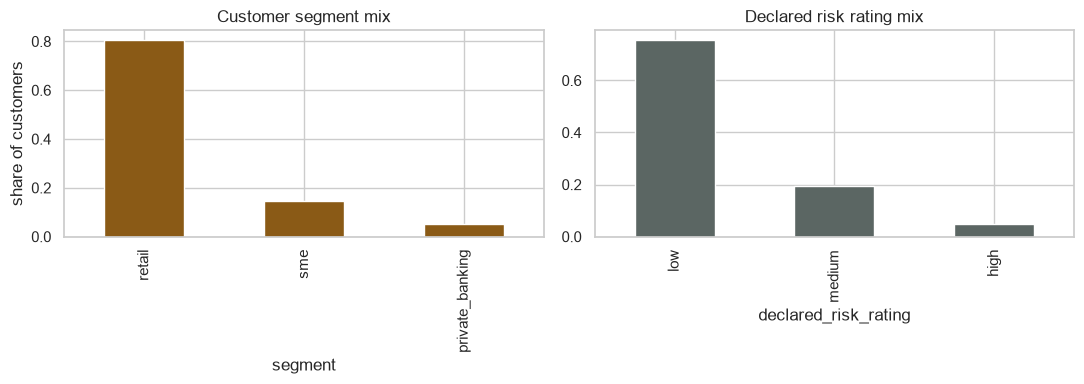

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
customers.segment.value_counts(normalize=True).plot.bar(ax=axes[0], color="#8A5A16")
axes[0].set_title("Customer segment mix")
axes[0].set_ylabel("share of customers")
customers.declared_risk_rating.value_counts(normalize=True).reindex(["low", "medium", "high"]).plot.bar(
    ax=axes[1], color="#5B6663"
)
axes[1].set_title("Declared risk rating mix")
plt.tight_layout()

## Transaction volume over time

Daily transaction count should be roughly flat with noise across the ~18-month window — no artificial seasonality was injected beyond a mild business-hours bias, so a strong trend here would indicate a generator bug.

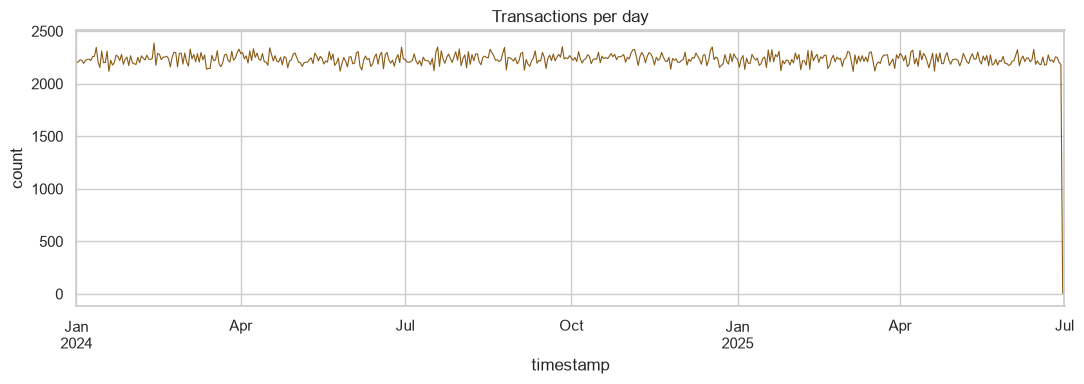

In [4]:
daily = transactions.set_index("timestamp").resample("D").size()
fig, ax = plt.subplots(figsize=(11, 4))
daily.plot(ax=ax, color="#8A5A16", linewidth=0.8)
ax.set_title("Transactions per day")
ax.set_ylabel("count")
plt.tight_layout()

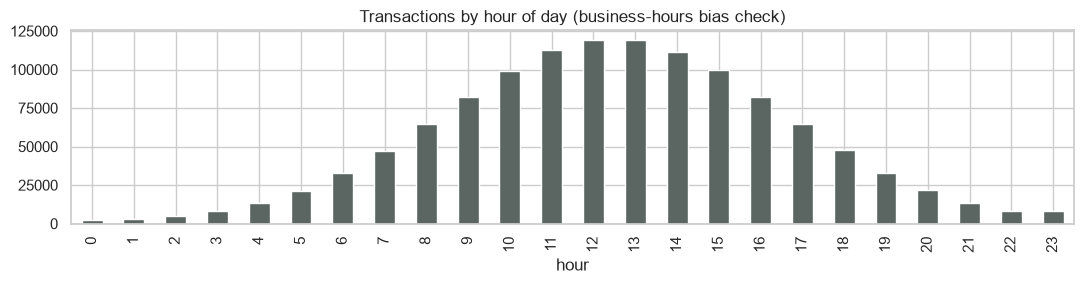

In [5]:
transactions.timestamp.dt.hour.value_counts().sort_index().plot.bar(figsize=(11, 3), color="#5B6663")
plt.title("Transactions by hour of day (business-hours bias check)")
plt.xlabel("hour")
plt.tight_layout()

## Amount distributions by segment

Retail / SME / private-banking amounts are lognormal with different location parameters (`SEGMENT_AMOUNT_PARAMS`). Plotting on a log axis should show three roughly-separated, right-skewed distributions.

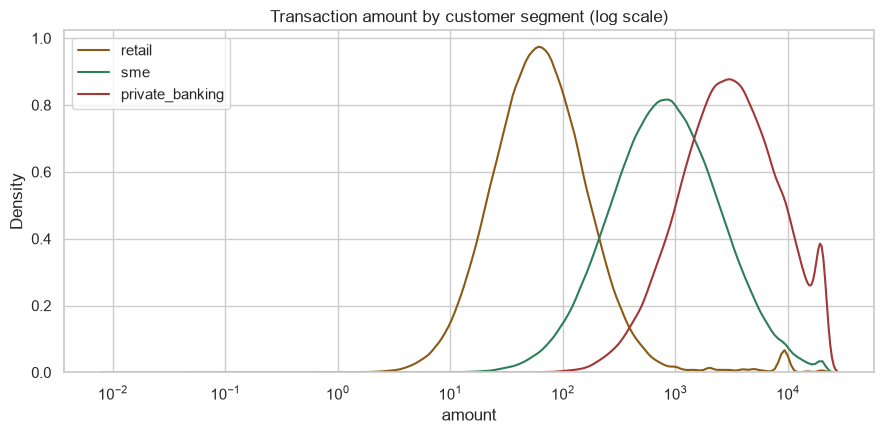

In [6]:
tx_seg = transactions.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")
fig, ax = plt.subplots(figsize=(9, 4.5))
for seg, color in zip(["retail", "sme", "private_banking"], ["#8A5A16", "#2E7D5B", "#A33636"]):
    sns.kdeplot(tx_seg.loc[tx_seg.segment == seg, "amount"].clip(upper=20_000), log_scale=True, label=seg, ax=ax, color=color)
ax.set_title("Transaction amount by customer segment (log scale)")
ax.legend()
plt.tight_layout()

## Channel, direction, and cross-border mix

overall cross-border rate: 10.17%


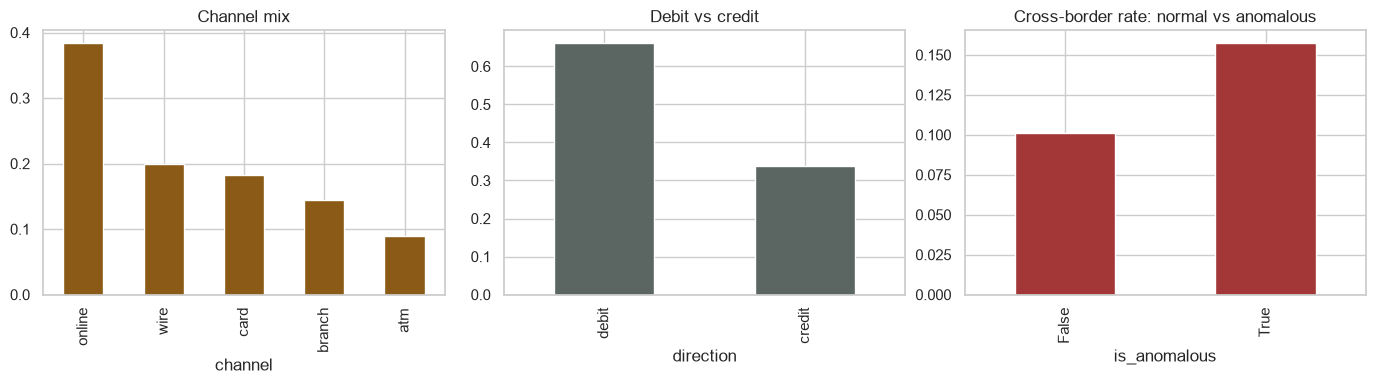

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
transactions.channel.value_counts(normalize=True).plot.bar(ax=axes[0], color="#8A5A16")
axes[0].set_title("Channel mix")
transactions.direction.value_counts(normalize=True).plot.bar(ax=axes[1], color="#5B6663")
axes[1].set_title("Debit vs credit")
print(f"overall cross-border rate: {transactions.is_cross_border.mean():.2%}")
transactions.groupby("is_anomalous").is_cross_border.mean().plot.bar(ax=axes[2], color="#A33636")
axes[2].set_title("Cross-border rate: normal vs anomalous")
plt.tight_layout()

## Injected typologies

Counts per typology, and where each one sits relative to normal activity — the point isn't that anomalies look wildly different on every axis (real suspicious activity often doesn't), it's that each typology should show *its own* distinctive signature consistent with how it was constructed in `data_sim/typologies.py`.

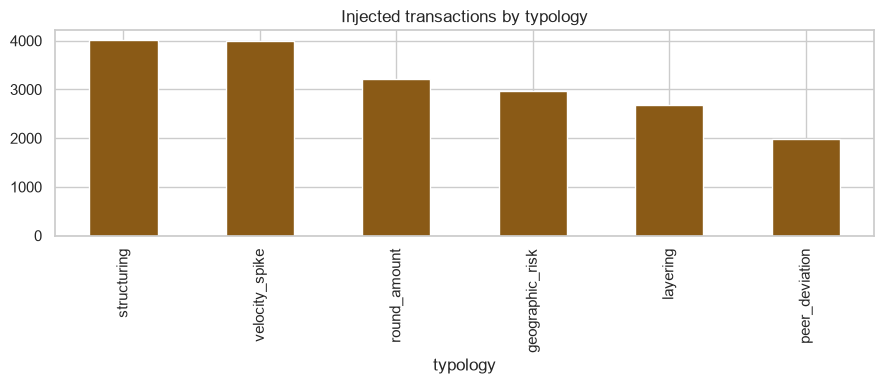

In [8]:
transactions.typology.value_counts(dropna=True).plot.bar(figsize=(9, 4), color="#8A5A16")
plt.title("Injected transactions by typology")
plt.tight_layout()

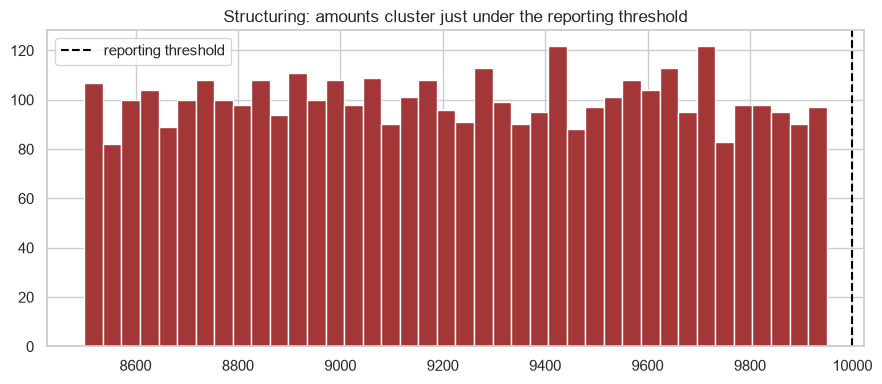

In [9]:
# structuring: amounts should cluster just under the reporting threshold
struct = transactions.loc[transactions.typology == "structuring", "amount"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(struct, bins=40, color="#A33636")
ax.axvline(manifest["reporting_threshold"], color="black", linestyle="--", label="reporting threshold")
ax.set_title("Structuring: amounts cluster just under the reporting threshold")
ax.legend()
plt.tight_layout()

In [10]:
# round_amount: should be exact multiples of 500, unlike normal lognormal amounts
round_amt = transactions.loc[transactions.typology == "round_amount", "amount"]
print("round_amount: share that are exact multiples of 500:", (round_amt % 500 == 0).mean())
normal_amt = transactions.loc[transactions.typology.isna(), "amount"]
print("normal transactions: share that are exact multiples of 500:", (normal_amt % 500 == 0).mean())

round_amount: share that are exact multiples of 500: 1.0
normal transactions: share that are exact multiples of 500: 1.1656292566282674e-05


In [11]:
# geographic_risk: should be ~100% cross-border, against a ~10% baseline
transactions.groupby("typology", dropna=False).is_cross_border.mean().sort_values(ascending=False)

typology
geographic_risk    0.999327
NaN                0.100822
layering           0.000000
peer_deviation     0.000000
round_amount       0.000000
structuring        0.000000
velocity_spike     0.000000
Name: is_cross_border, dtype: float64

## Leakage sanity check

Per the risk register, the worry with synthetic data is a typology that's *too* separable on a single raw field — that would make Week 2/3 precision numbers meaningless (the model would just be learning the injection rule, not detecting anomalous behaviour). Amount alone should **not** cleanly separate anomalous from normal transactions overall — the six typologies are deliberately heterogeneous (some are about amount, some about timing, some about counterparty geography), so no single field should dominate.

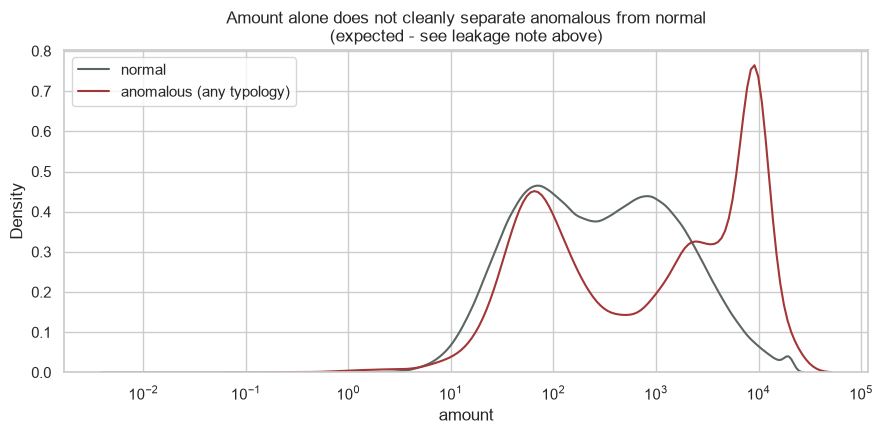

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.kdeplot(transactions.loc[~transactions.is_anomalous, "amount"].clip(upper=20_000), log_scale=True, label="normal", ax=ax, color="#5B6663")
sns.kdeplot(transactions.loc[transactions.is_anomalous, "amount"].clip(upper=20_000), log_scale=True, label="anomalous (any typology)", ax=ax, color="#A33636")
ax.set_title("Amount alone does not cleanly separate anomalous from normal\n(expected - see leakage note above)")
ax.legend()
plt.tight_layout()

## Takeaways

- Scale, date range, and injected anomaly rate all land close to the configured targets (see manifest above).
- Each typology shows a distinctive signature consistent with its construction (structuring under-threshold, round_amount on exact multiples, geographic_risk ~100% cross-border) — but none is trivially separable on a single raw field, which is what makes the Week 2/3 feature-engineering step meaningful rather than circular.
- Next: `features/` — velocity, peer-group deviation, and round-amount features (`PLAN.md` §04), then the Isolation Forest baseline (`PLAN.md` §05).